In [141]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.preprocessing import MinMaxScaler, OneHotEncoder, MultiLabelBinarizer
from sklearn.decomposition import PCA
from sklearn.model_selection import train_test_split, cross_val_score
from sklearn.linear_model import LinearRegression, LogisticRegression
from sklearn.metrics import mean_squared_error, r2_score, classification_report, accuracy_score, confusion_matrix
from scipy.optimize import curve_fit
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

In [142]:
df = pd.read_csv("datos/datos.csv")

In [143]:
df.head()
df.describe()

,appid,required_age,achievements,positive_ratings,negative_ratings,average_playtime,median_playtime,price,copiessold,revenue,firstreleasedate,reviewscore
count,2.323000e+04,23230.000000,23230.000000,23230.000000,23230.000000,23230.000000,23230.000000,23230.000000,2.323000e+04,2.323000e+04,2.323000e+04,23230.000000
mean,5.916447e+05,0.294791,38.654283,357.344727,82.258674,107.152217,112.587000,5.886544,6.482484e+04,2.605762e+05,1.481585e+12,70.916746
std,2.486956e+05,2.185441,310.533420,2653.099238,729.596943,1714.138494,2066.700829,6.258438,5.067301e+05,1.087396e+06,6.529230e+10,20.940744
min,2.000000e+01,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000,0.000000e+00,0.000000e+00,9.229428e+11,0.000000
25%,3.978025e+05,0.000000,0.000000,6.000000,2.000000,0.000000,0.000000,1.690000,5.400000e+02,5.640000e+02,1.455512e+12,59.000000
50%,5.908300e+05,0.000000,8.000000,24.000000,8.000000,0.000000,0.000000,3.990000,3.213000e+03,5.133000e+03,1.499314e+12,75.000000
75%,7.908475e+05,0.000000,23.000000,118.000000,37.000000,0.000000,0.000000,7.190000,1.898500e+04,4.965075e+04,1.527134e+12,87.000000
max,1.069460e+06,18.000000,9821.000000,292574.000000,91664.000000,190625.000000,190625.000000,154.990000,5.355018e+07,1.229418e+07,1.682482e+12,100.000000


In [144]:
df_filtrado = df.drop(columns=['unreleased', 'nombre', 'appid'])

In [145]:
# Definimos el umbral para clasificar
threshold = 100000

In [146]:
# Probemos un enfoque distinto, en cambio crearemos una nueva columna con un 'threshold' de playtime y haremos clasificación.
# Es decir, si el playtime es mayor a X horas, clase 1, sino clase 0.
df_filtrado['high_sales'] = (df_filtrado['copiessold'] > threshold).astype(int)

# Creamos también una columna que sea la razón entre rating positivos y negativos
df_filtrado['rating_ratio'] = df_filtrado['positive_ratings'] / (df_filtrado['negative_ratings'] + 1)  # +1 para evitar división por cero

X = df_filtrado.drop(columns=["average_playtime", "high_sales", "median_playtime", "owners", "revenue", "positive_ratings", "negative_ratings", "copiessold"]).copy()
y = df_filtrado["high_sales"].copy()

columnas_cuantitativas = ["price", "required_age", "achievements", "rating_ratio", "reviewscore"]
columnas_lista = ["platforms", "genres", "categories"]


df_cuantitativo = X[columnas_cuantitativas].copy()
df_lista = X[columnas_lista].copy()
df_cualitativo = X.drop(columns=list(df_cuantitativo.columns) + list(df_lista.columns)).copy()

df_binarizado_total = pd.DataFrame()

for columna in columnas_lista:
    listas = df_lista[columna].fillna('').str.split(';')
    mlb = MultiLabelBinarizer()
    datos_binarizados = mlb.fit_transform(listas)
    df_temp = pd.DataFrame(datos_binarizados,
                           columns=mlb.classes_,
                           index=df_lista.index).add_prefix(f'{columna}_')
    df_binarizado_total = pd.concat([df_binarizado_total, df_temp], axis=1)

generos_binarizados = mlb.fit_transform(df_lista)

encoder = OneHotEncoder(
    min_frequency=100, # Agrupa categorías que aparecen menos de 100 veces
    handle_unknown='ignore',
    dtype=np.float32,
    drop="first"
)

result = encoder.fit_transform(df_cualitativo).toarray()

column_names = encoder.get_feature_names_out(df_cualitativo.columns)

data_scaled = pd.DataFrame(result, columns=column_names, index=df_cualitativo.index)
# df_encoded = pd.concat([data_scaled, df_cuantitativo, df_binarizado_total], axis=1)
df_encoded = pd.concat([data_scaled, df_cuantitativo], axis=1)
df_encoded.head()

scaler = MinMaxScaler()
#Falta OneHotEncoder y lo que hice arriba con el multilabel (mañana lo termino antes de la reu)
X_scaled = scaler.fit_transform(df_encoded)
X_scaled = pd.DataFrame(X_scaled, columns=df_encoded.columns, index=df_encoded.index)


pca = PCA(n_components=min(27, X_scaled.shape[1]))
X_pca = pca.fit_transform(X_scaled)
explained = pca.explained_variance_ratio_.sum()
print(f"Dimensión tras PCA: {X_pca.shape}, varianza explicada acumulada: {explained:.3f}")

Dimensión tras PCA: (23230, 27), varianza explicada acumulada: 0.959


# SECCION PCA

In [147]:
X_train_PCA, X_test_PCA, y_train_PCA, y_test_PCA = train_test_split(X_pca, y, test_size=0.2, random_state=42)

### Regresión Logística

In [148]:
# Aplicaremos Regresión Logística
logistic = LogisticRegression(random_state=42, max_iter=1000)
logistic.fit(X_train_PCA, y_train_PCA)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [149]:
# Testamos el modelo
y_pred_log_PCA = logistic.predict(X_test_PCA)

# Classification report
print(classification_report(y_test_PCA, y_pred_log_PCA))
print(confusion_matrix(y_test_PCA, y_pred_log_PCA))


              precision    recall  f1-score   support

           0       0.92      0.99      0.95      4201
           1       0.69      0.16      0.26       445

    accuracy                           0.91      4646
   macro avg       0.81      0.57      0.60      4646
weighted avg       0.90      0.91      0.89      4646

[[4170   31]
 [ 375   70]]


In [150]:
# Veamos las componentes que más pesan en la regresión logística
coeficientes_log = pd.Series(logistic.coef_[0], index=[f'PC{i+1}' for i in range(X_pca.shape[1])])
coeficientes_log = coeficientes_log.abs().sort_values(ascending=False).head(10)
print("Top 10 componentes principales más importantes en la regresión logística:")
print(coeficientes_log)

Top 10 componentes principales más importantes en la regresión logística:
PC4     5.272641
PC2     2.253773
PC1     1.566848
PC8     1.561184
PC17    1.485005
PC7     1.127629
PC3     1.064173
PC14    1.046958
PC10    0.880188
PC21    0.854968
dtype: float64


## Random Forest

In [151]:
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=8,
    max_features='sqrt',
    oob_score=True,
    random_state=42
)
rf.fit(X_train_PCA, y_train_PCA)
yhat_rf_train = rf.predict(X_train_PCA)
yhat_rf_test = rf.predict(X_test_PCA)

In [152]:
print('Random Forest - Accuracy train:', accuracy_score(y_train_PCA, yhat_rf_train))
print('Random Forest - Accuracy test :', accuracy_score(y_test_PCA, yhat_rf_test))
print('OOB score:', rf.oob_score_)

Random Forest - Accuracy train: 0.9232673267326733
Random Forest - Accuracy test : 0.9151958674128282
OOB score: 0.9133663366336634


In [153]:
print('\nReporte (test):\n', classification_report(y_test_PCA, yhat_rf_test))
print('Matriz de confusión (test):\n', confusion_matrix(y_test_PCA, yhat_rf_test))


Reporte (test):
               precision    recall  f1-score   support

           0       0.92      0.99      0.95      4201
           1       0.71      0.20      0.31       445

    accuracy                           0.92      4646
   macro avg       0.81      0.59      0.63      4646
weighted avg       0.90      0.92      0.89      4646

Matriz de confusión (test):
 [[4165   36]
 [ 358   87]]


In [154]:
# Queremos ver ahora las features más importantes según el Random Forest
nombres = [f'PC{i+1}' for i in range(X_pca.shape[1])]

importancias = pd.Series(rf.feature_importances_, index=nombres)
importancias = importancias.sort_values(ascending=False).head(10)
print("Top 10 componentes principales más importantes según Random Forest:")
print(importancias)

Top 10 componentes principales más importantes según Random Forest:
PC5     0.091235
PC1     0.069053
PC14    0.068660
PC2     0.064950
PC11    0.057234
PC4     0.057190
PC6     0.045664
PC18    0.039307
PC12    0.038921
PC3     0.038626
dtype: float64


### KNN

Mejor K según CV: 5


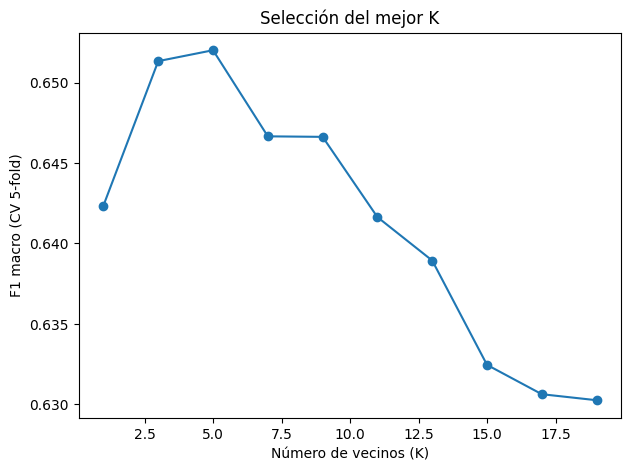

In [155]:
k_values = range(1, 21, 2)
scores = []
for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    cv_score = cross_val_score(knn, X_train_PCA, y_train_PCA, cv=5, scoring="f1_macro").mean()
    scores.append(cv_score)

best_k = k_values[np.argmax(scores)]
print("Mejor K según CV:", best_k)

plt.figure(figsize=(7,5))
plt.plot(k_values, scores, marker="o")
plt.xlabel("Número de vecinos (K)")
plt.ylabel("F1 macro (CV 5-fold)")
plt.title("Selección del mejor K")
plt.show()

In [156]:
# Aplicamos KNN con el mejor K
knn = KNeighborsClassifier(n_neighbors=best_k)
knn.fit(X_train_PCA, y_train_PCA)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [157]:
# Sacamos predicciones
y_pred_knn_PCA = knn.predict(X_test_PCA)

# Classification report
print(classification_report(y_test_PCA, y_pred_knn_PCA))
print(confusion_matrix(y_test_PCA, y_pred_knn_PCA))

              precision    recall  f1-score   support

           0       0.92      0.97      0.95      4201
           1       0.48      0.24      0.32       445

    accuracy                           0.90      4646
   macro avg       0.70      0.61      0.64      4646
weighted avg       0.88      0.90      0.89      4646

[[4086  115]
 [ 337  108]]


# SECCIÓN SIN PCA

In [158]:
X_train, X_test, y_train, y_test = train_test_split(X_scaled, y, test_size=0.2, random_state=42)

### Regresión Logística

In [159]:
# Haremos lo mismo pero sin PCA
logistic_full = LogisticRegression(random_state=42, max_iter=1000)
logistic_full.fit(X_train, y_train)

,penalty,'l2'
,dual,False
,tol,0.0001
,C,1.0
,fit_intercept,True
,intercept_scaling,1
,class_weight,None
,random_state,42
,solver,'lbfgs'
,max_iter,1000
,multi_class,'deprecated'


In [160]:
# Testamos el modelo
y_pred_log = logistic_full.predict(X_test)

# Classification report
print(classification_report(y_test, y_pred_log))
print(confusion_matrix(y_test, y_pred_log))


              precision    recall  f1-score   support

           0       0.92      0.99      0.95      4201
           1       0.68      0.16      0.26       445

    accuracy                           0.91      4646
   macro avg       0.80      0.58      0.61      4646
weighted avg       0.90      0.91      0.89      4646

[[4168   33]
 [ 374   71]]


In [161]:
# Veamos los componentes que más pesan en la regresión logística SIN PCA
coeficientes_log_full = pd.Series(logistic_full.coef_[0], index=X_scaled.columns)
coeficientes_log_full = coeficientes_log_full.abs().sort_values(ascending=False).head(10)
print("Top 10 variables más importantes en la regresión logística sin PCA:")
print(coeficientes_log_full)

Top 10 variables más importantes en la regresión logística sin PCA:
reviewscore                                     4.306274
publisherclass_Hobbyist                         2.849057
steamspy_tags_infrequent_sklearn                2.009751
steamspy_tags_Adventure;Casual;Hidden Object    1.913944
rating_ratio                                    1.859853
price                                           1.354317
english_t                                       1.336013
publisherclass_Indie                            1.325755
required_age                                    1.162545
publisher_infrequent_sklearn                    1.134425
dtype: float64


### Random Forest

In [162]:
rf = RandomForestClassifier(
    n_estimators=200,
    max_depth=12,
    max_features='sqrt',
    oob_score=True,
    random_state=42
)
rf.fit(X_train, y_train)
yhat_rf_train = rf.predict(X_train)
yhat_rf_test = rf.predict(X_test)

In [163]:
print('Random Forest - Accuracy train:', accuracy_score(y_train_PCA, yhat_rf_train))
print('Random Forest - Accuracy test :', accuracy_score(y_test_PCA, yhat_rf_test))
print('OOB score:', rf.oob_score_)

Random Forest - Accuracy train: 0.9282178217821783
Random Forest - Accuracy test : 0.9145501506672407
OOB score: 0.9150882479552304


In [164]:
print('\nReporte (test):\n', classification_report(y_test, yhat_rf_test))
print('Matriz de confusión (test):\n', confusion_matrix(y_test, yhat_rf_test))


Reporte (test):
               precision    recall  f1-score   support

           0       0.92      0.99      0.95      4201
           1       0.73      0.17      0.28       445

    accuracy                           0.91      4646
   macro avg       0.82      0.58      0.62      4646
weighted avg       0.90      0.91      0.89      4646

Matriz de confusión (test):
 [[4173   28]
 [ 369   76]]


In [165]:
# Queremos ver ahora las features más importantes según el Random Forest, ahora SIN PCA
nombres = X_scaled.columns
importancias = pd.Series(rf.feature_importances_, index=nombres)
importancias = importancias.sort_values(ascending=False).head(10)
print("Top 10 variables más importantes según Random Forest sin PCA:")
print(importancias)

Top 10 variables más importantes según Random Forest sin PCA:
rating_ratio                        0.182478
price                               0.181730
reviewscore                         0.153750
achievements                        0.128818
publisherclass_Hobbyist             0.086157
publisherclass_AAA                  0.079351
publisherclass_Indie                0.075892
steamspy_tags_infrequent_sklearn    0.045262
required_age                        0.033907
earlyaccess_True                    0.006831
dtype: float64


### KNN

Mejor K según CV: 5


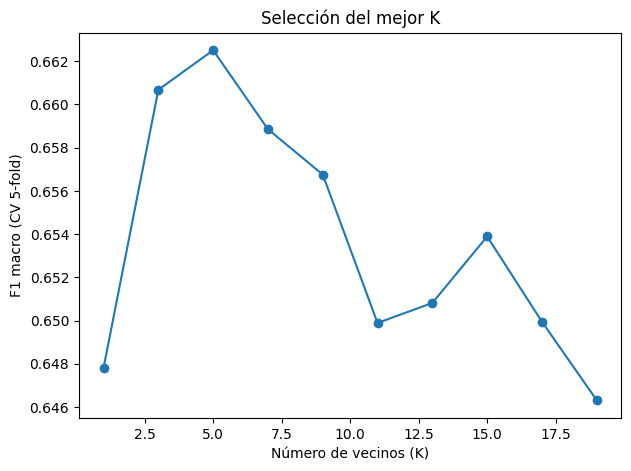

In [166]:
k_values = range(1, 21, 2)
scores = []
for k in k_values:
    knn = KNeighborsClassifier(n_neighbors=k)
    cv_score = cross_val_score(knn, X_train, y_train, cv=5, scoring="f1_macro").mean()
    scores.append(cv_score)

best_k = k_values[np.argmax(scores)]
print("Mejor K según CV:", best_k)

plt.figure(figsize=(7,5))
plt.plot(k_values, scores, marker="o")
plt.xlabel("Número de vecinos (K)")
plt.ylabel("F1 macro (CV 5-fold)")
plt.title("Selección del mejor K")
plt.show()

In [167]:
# Aplicamos KNN con el mejor K
knn = KNeighborsClassifier(n_neighbors=best_k)
knn.fit(X_train, y_train)

,n_neighbors,5
,weights,'uniform'
,algorithm,'auto'
,leaf_size,30
,p,2
,metric,'minkowski'
,metric_params,None
,n_jobs,None


In [168]:
# Sacamos predicciones
y_pred_knn = knn.predict(X_test)

# Classification report
print(classification_report(y_test, y_pred_knn))
print(confusion_matrix(y_test, y_pred_knn))

              precision    recall  f1-score   support

           0       0.93      0.97      0.95      4201
           1       0.53      0.28      0.36       445

    accuracy                           0.91      4646
   macro avg       0.73      0.63      0.66      4646
weighted avg       0.89      0.91      0.89      4646

[[4093  108]
 [ 322  123]]
